# DATA555 Project 1: Predicting Sales with Multiple Linear Regression

**Question:** How well can TV, Radio, Social Media, and Influencer type predict Sales in the Dummy Marketing and Sales dataset?

Data source: [Dummy Marketing and Sales Data by Harriman Samuel Saragih](https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data). This is a dummy dataset. Keep `Dummy Data HSS.csv` in the same folder as this notebook and run the cells from top to bottom.

## 1. Data Preparation and Quality Check

First, inspect the columns, data types, missing values, duplicate rows, category labels, and numerical summaries. These checks show what must be cleaned before modeling.

In [3]:
import pandas as pd

marketing_data = pd.read_csv('Dummy Data HSS.csv')

print('Shape:', marketing_data.shape)
print('\nColumns:', marketing_data.columns.tolist())
print('\nData types:\n', marketing_data.dtypes)
print('\nMissing values:\n', marketing_data.isnull().sum())
print('\nDuplicate rows:', marketing_data.duplicated().sum())
print('\nInfluencer categories:', marketing_data['Influencer'].unique())
print('\nCategory counts:\n', marketing_data['Influencer'].value_counts())
print('\nNumerical summary:\n', marketing_data.describe())

Shape: (4572, 5)

Columns: ['TV', 'Radio', 'Social Media', 'Influencer', 'Sales']

Data types:
 TV              float64
Radio           float64
Social Media    float64
Influencer          str
Sales           float64
dtype: object

Missing values:
 TV              10
Radio            4
Social Media     6
Influencer       0
Sales            6
dtype: int64

Duplicate rows: 0

Influencer categories: <StringArray>
['Mega', 'Micro', 'Nano', 'Macro']
Length: 4, dtype: str

Category counts:
 Influencer
Mega     1158
Micro    1153
Nano     1139
Macro    1122
Name: count, dtype: int64

Numerical summary:
                 TV        Radio  Social Media        Sales
count  4562.000000  4568.000000   4566.000000  4566.000000
mean     54.066857    18.160356      3.323956   192.466602
std      26.125054     9.676958      2.212670    93.133092
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.525957      1.527849   112.322882
50%      53.000000    17.859513      3.0555

The original dataset has 4,572 rows and five columns. There are missing values in four columns and no duplicate rows, so I remove rows with missing values before making plots or training the model. This removes 26 rows and leaves 4,546 complete rows.

In [4]:
rows_before = len(marketing_data)
marketing_data = marketing_data.dropna().copy()

print('Rows removed:', rows_before - len(marketing_data))
print('Shape after cleaning:', marketing_data.shape)
print('\nMissing values after cleaning:\n', marketing_data.isnull().sum())

Rows removed: 26
Shape after cleaning: (4546, 5)

Missing values after cleaning:
 TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64


## 2. Exploratory Data Analysis (EDA)

Scatter plots show how each numerical advertising variable relates to Sales before the other variables are controlled for.

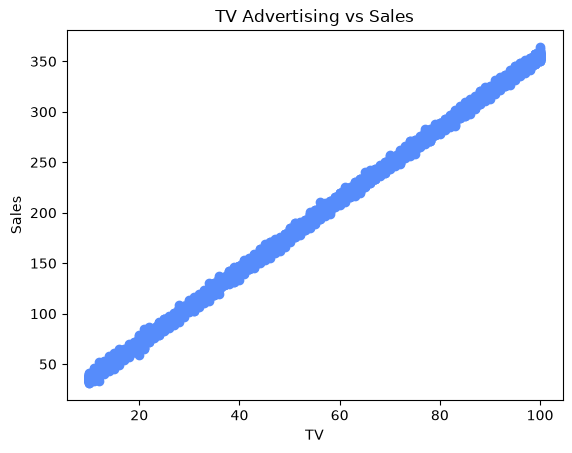

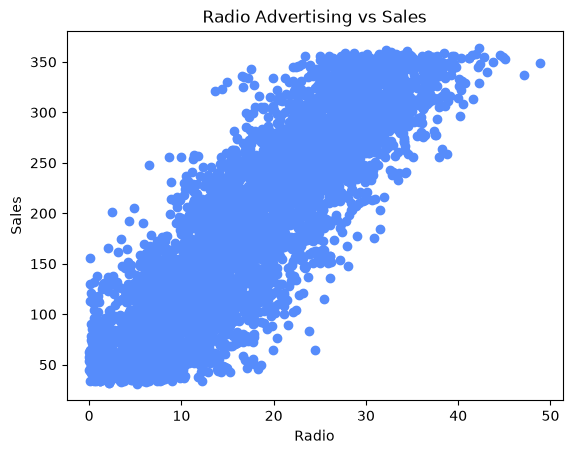

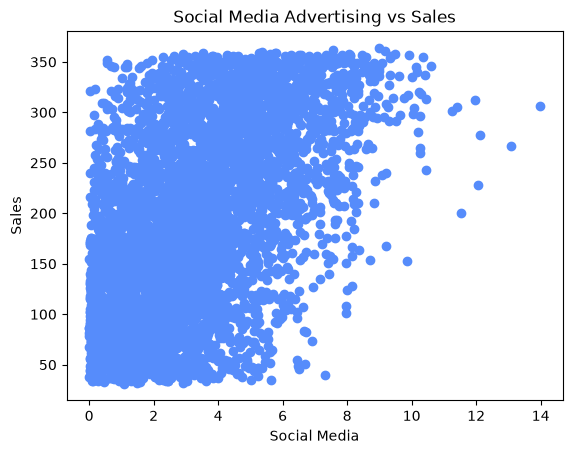

In [5]:
import matplotlib.pyplot as plt

plt.scatter(marketing_data['TV'], marketing_data['Sales'])
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV Advertising vs Sales')
plt.show()

plt.scatter(marketing_data['Radio'], marketing_data['Sales'])
plt.xlabel('Radio')
plt.ylabel('Sales')
plt.title('Radio Advertising vs Sales')
plt.show()

plt.scatter(marketing_data['Social Media'], marketing_data['Sales'])
plt.xlabel('Social Media')
plt.ylabel('Sales')
plt.title('Social Media Advertising vs Sales')
plt.show()

TV and Sales follow a strong, nearly straight upward pattern. Radio also has a positive pattern but much more spread, while the Social Media plot is even more scattered. These plots describe each pair of variables separately; they do not show the extra association of one predictor after accounting for the others.

The bar chart compares average Sales across the four Influencer categories. It provides a simple view of the categorical variable before encoding.

Influencer
Macro    196.066150
Mega     190.412908
Micro    191.578370
Nano     191.708827
Name: Sales, dtype: float64


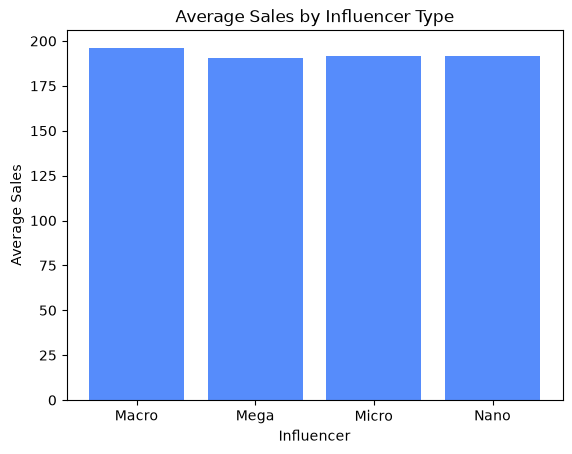

In [6]:
influencer_sales = marketing_data.groupby('Influencer')['Sales'].mean()
print(influencer_sales)

plt.bar(influencer_sales.index, influencer_sales.values)
plt.xlabel('Influencer')
plt.ylabel('Average Sales')
plt.title('Average Sales by Influencer Type')
plt.show()

The four category averages are close (about 190–196 Sales units). This comparison is unadjusted, so differences may also reflect the other advertising variables.

## 3. Categorical Variable Encoding

`Influencer` is a categorical variable, but linear regression needs numerical inputs. Dummy encoding creates one 0/1 column for each non-reference category. With `drop_first=True`, **Macro** is the reference category, represented by zeros in the Mega, Micro, and Nano columns.

**AI use disclosure:** I asked chatgpt how to handle the `Influencer` categories for multiple linear regression. The original prompt and reply are not in the uploaded notebook; the following is an accurate summary rather than a verbatim transcript. The advice was to use `pd.get_dummies` with `drop_first=True` and integer dummy columns. I checked the four original category names and the three encoded column names below. I checked that Macro rows have zeros in all three dummy columns. I confirmed that encoding keeps all 4,546 complete rows and that Sales remains the target rather than an input feature. I then reran the regression and compared its results with the original notebook. These checks verify the code behavior, while the plots and model results come from the data rather than from ChatGPT.And the format of Markdown asked chatgpt also.



In [7]:
model_data = pd.get_dummies(
    marketing_data,
    columns=['Influencer'],
    drop_first=True,
    dtype=int
)

dummy_columns = [column for column in model_data.columns if column.startswith('Influencer_')]
print('Encoded columns:', model_data.columns.tolist())
print('Shape after encoding:', model_data.shape)
print('\nFirst five rows:\n', model_data.head())
print('\nMacro example (all dummy values should be 0):\n',
      model_data.loc[marketing_data['Influencer'] == 'Macro', dummy_columns].head(1))

Encoded columns: ['TV', 'Radio', 'Social Media', 'Sales', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']
Shape after encoding: (4546, 7)

First five rows:
      TV      Radio  Social Media       Sales  Influencer_Mega  \
0  16.0   6.566231      2.907983   54.732757                1   
1  13.0   9.237765      2.409567   46.677897                1   
2  41.0  15.886446      2.913410  150.177829                1   
3  83.0  30.020028      6.922304  298.246340                1   
4  15.0   8.437408      1.405998   56.594181                0   

   Influencer_Micro  Influencer_Nano  
0                 0                0  
1                 0                0  
2                 0                0  
3                 0                0  
4                 1                0  

Macro example (all dummy values should be 0):
    Influencer_Mega  Influencer_Micro  Influencer_Nano
8                0                 0                0
